# Imports

In [151]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

import csv

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# Data Cleaning

### Functions

In [156]:
def comma_to_left(string, index) -> bool:
    '''
    Checks if there is a comma to the left of the index in the string, ignoring spaces.
    '''
    while index >= 1:
        if string[index - 1] == ',':
            return True
        if string[index - 1] == ' ':
            index -= 1
        else:
            return False
    return False

def strip_optional_tags(string):
    '''
    Strips "optional" tags from the string, and strips descriptions of ingredients in parentheses
    '''
    # First, remove simple substrings
    string = string.replace("[", "").replace("]", "")
    string = string.replace("optionally", "").replace("optional", "")
    string = string.replace(":", "")
    string = string.replace("{", "").replace("}", "")
    
    # Handle parentheses: find all "("s
    # If no comma to the left, delete everything from "(" to ")"
    # If comma to the left, just delete "(" and ")"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            
            # Check if there's a comma to the left
            if comma_to_left(string, i):
                # Just delete "(" and ")", keep the content
                result.append(string[i+1:close_idx])
                i = close_idx + 1
            else:
                # Delete all text from "(" to ")" inclusive
                i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result)

def strip_optional_ingredients(string): # MAY NOT WORK
    '''
    Strips "optional" ingredients from the string, as well as descriptions of ingredients in parentheses.
    '''
    # First pass: Look for "(" or "[" from left to right
    # If one is found and there's a comma to the left, delete everything from that comma to the end
    i = 0
    while i < len(string):
        if string[i] in '([':
            if comma_to_left(string, i):
                # Delete everything from the comma to the end of the string
                j = i - 1
                while j >= 0:
                    if string[j] == ',':
                        string = string[:j]
                        break
                    j -= 1
                break
        i += 1
    
    # Second pass: Search for "(optional)" and "[optional]" repeatedly
    while True:
        idx1 = string.find("(optional)")
        idx2 = string.find("[optional]")
        
        if idx1 == -1 and idx2 == -1:
            break
        
        # Find which one comes first
        idx = -1
        pattern_len = 0
        if idx1 != -1 and idx2 != -1:
            idx = min(idx1, idx2)
            pattern_len = 10 if idx == idx1 else 10
        elif idx1 != -1:
            idx = idx1
            pattern_len = 10
        else:
            idx = idx2
            pattern_len = 10
        
        # Find the first comma to the left, delete from comma to end of pattern
        j = idx - 1
        comma_idx = -1
        while j >= 0:
            if string[j] == ',':
                comma_idx = j
                break
            j -= 1
        
        if comma_idx != -1:
            # Delete from comma to the end of the pattern
            string = string[:comma_idx] + string[idx + pattern_len:]
        else:
            # No comma found, just remove the pattern
            string = string[:idx] + string[idx + pattern_len:]
    
    # Final pass: Strip everything in parentheses, including the parentheses themselves
    # get rid of the descriptions of ingredients in parentheses, e.g. "kalabasa (squash)"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            # Skip everything from "(" to ")" inclusive
            i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result).strip()


def clean_ingredient_list(string):
    '''
    Strips whitespace and empty ingredients so that we can easily split by comma to get a clean list
    Also splits on "and", "or" and "/" and removes periods
    '''
    normalized = re.sub(r"\bor\b", ",", string, flags=re.IGNORECASE)
    normalized = re.sub(r"\band\b", ",", normalized, flags=re.IGNORECASE)
    normalized = re.sub(r"/", ",", normalized, flags=re.IGNORECASE)
    return [ingredient.lower().replace(".", "").strip() for ingredient in normalized.split(",") if ingredient.strip()]

def countries_to_array(string):
    '''
    Converts a string of countries separated by semicolons into an array of countries, stripping whitespace.
    '''
    return [country.strip() for country in string.split(";") if country.strip()]

#### Testing

In [157]:
print(strip_optional_tags("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_tags("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_tags("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_tags("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_tags("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_tags("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_tags("salt, (optional garlic), (optional sugar)"))
print(strip_optional_tags("salt, kalabasa (squash)"))
print(strip_optional_tags("salt, kalabasa (squash), (optional) garlic"))

print("\n" + strip_optional_tags("salt, sugar, (optionally pepper), (optional garlic)"))
print(strip_optional_tags("Cold noodles, sliced beef, beef broth, kimchi, boiled egg, cucumber, radish, (optional pickled mustard greens, optional apple slices, optional sesame seeds)."))
print(strip_optional_tags("salt, (mushrooms optional), (peas optional),"))

salt, sugar, pepper , garlic , onion 
salt,  garlic, sugar, etc.
salt, sugar, pepper , garlic , onion 
salt, sugar,  pepper,  garlic,  onion
salt, green onions , red onions 
salt,  garlic,  sugar
salt,  garlic,  sugar
salt, kalabasa 
salt, kalabasa ,  garlic

salt, sugar,  pepper,  garlic
Cold noodles, sliced beef, beef broth, kimchi, boiled egg, cucumber, radish,  pickled mustard greens,  apple slices,  sesame seeds.
salt, mushrooms , peas ,


In [158]:
print(strip_optional_ingredients("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_ingredients("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_ingredients("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_ingredients("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_ingredients("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_ingredients("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_ingredients("salt, (optional garlic), (optional sugar)"))
print(strip_optional_ingredients("salt, kalabasa (squash)"))
print(strip_optional_ingredients("salt, kalabasa (squash), (optional) garlic"))

salt, sugar
salt
salt, sugar
salt, sugar
salt
salt
salt
salt, kalabasa
salt, kalabasa


In [159]:
clean_ingredient_list("salt   , meat or fish, and shrimp,     onion/shallot, etc")

['salt', 'meat', 'fish', 'shrimp', 'onion', 'shallot', 'etc']

### Overview / optional ingredient processing

In [160]:
df = pd.read_csv('data.csv')

cleaned_df = df.copy().drop("alternate_names", axis=1)

cleaned_df['ingredients'] = cleaned_df['ingredients'].apply(strip_optional_tags).apply(clean_ingredient_list)
cleaned_df['countries_of_origin'] = cleaned_df['countries_of_origin'].apply(countries_to_array)

In [161]:
cleaned_df.head()

,dish_name,countries_of_origin,ingredients
0,Cepelinai,[Lithuania],"[potatoes, ground meat, onions, bacon, sour cr..."
1,Msabbaha,"[Oman, Jordan, Bahrain, Palestine, Qatar, Unit...","[chickpeas, tahini, lemon juice, garlic, olive..."
2,Lazarakia,"[Greece, Cyprus]","[flour, yeast, water, sugar, olive oil, salt, ..."
3,Dressed Crab,[United Kingdom],"[crab meat, mayonnaise, lemon juice, breadcrum..."
4,Dak-galbi,[South Korea],"[chicken, gochujang, soy sauce, garlic, ginger..."


In [162]:
cleaned_df['countries_of_origin'].explode().value_counts().head(15) / len(cleaned_df) * 100.0

countries_of_origin
United States     6.566667
Japan             4.833333
Indonesia         4.433333
United Kingdom    4.400000
China             4.400000
Italy             4.366667
Philippines       4.266667
India             3.733333
Spain             3.733333
France            3.666667
Germany           3.300000
South Korea       3.266667
Canada            3.100000
Turkey            2.633333
North Korea       2.533333
Name: count, dtype: float64

In [163]:
# filter out duplicates
unique_dishes_df = cleaned_df.drop_duplicates(subset=['dish_name'])
len(unique_dishes_df)

1742

<Axes: xlabel='count', ylabel='Count'>

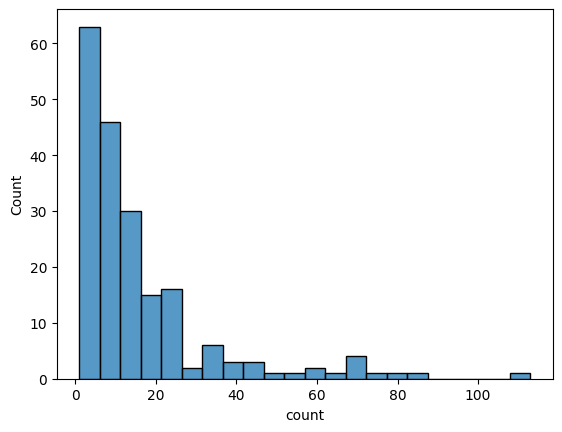

In [164]:
sns.histplot(unique_dishes_df['countries_of_origin'].explode().value_counts())

In [165]:
# countries included if cutting off least frequent 150 countries
unique_dishes_df['countries_of_origin'].explode().value_counts().head(197 - 150)

countries_of_origin
United States     113
Japan              83
United Kingdom     80
China              73
Italy              72
Indonesia          72
Philippines        71
India              70
France             66
Spain              62
Germany            60
South Korea        53
Canada             51
Thailand           46
Turkey             43
Mexico             43
Malaysia           40
North Korea        40
Vietnam            37
Peru               35
Iran               34
Georgia            34
Australia          34
Brazil             32
Singapore          32
Sweden             31
Azerbaijan         28
Poland             26
Russia             26
Armenia            26
Taiwan             25
Algeria            25
Romania            24
Nepal              24
Pakistan           24
Greece             23
Colombia           23
Egypt              23
Hong Kong          23
Myanmar            22
Tunisia            22
Netherlands        22
Bangladesh         22
New Zealand        21
Ukraine     

In [166]:
unique_dishes_df['countries_of_origin'].explode().value_counts().iloc[50:100]

countries_of_origin
Portugal                  20
Serbia                    20
Denmark                   19
Sri Lanka                 19
Lithuania                 19
Nigeria                   19
Lebanon                   17
Belarus                   17
Morocco                   16
Belgium                   16
Bulgaria                  16
Chile                     16
South Africa              16
Syria                     16
Slovenia                  16
Palestine                 16
Cyprus                    15
Libya                     15
Norway                    15
Jordan                    15
Switzerland               15
Cuba                      14
Ecuador                   14
Ireland                   14
Trinidad and Tobago       14
Bolivia                   14
Laos                      14
Iraq                      14
Bosnia and Herzegovina    13
North Macedonia           13
Moldova                   13
Israel                    13
Macau                     13
Mauritania             

### Collapse similar ingredient variants (plural, spacing, accents, etc.)

In [167]:
import inflect
import unicodedata
import re

p = inflect.engine()

# Normalize ingredient strings to collapse accent, apostrophe, and hyphen variants,
# while preserving spaces so canonical multi-word ingredients stay spaced.
def normalize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = unicodedata.normalize('NFKD', ingredient)
    ingredient = ''.join(ch for ch in ingredient if not unicodedata.combining(ch))
    ingredient = ingredient.lower()
    ingredient = ingredient.replace('-', ' ')
    ingredient = re.sub(r"[’`´]", "'", ingredient)
    ingredient = ingredient.replace("'", '')
    ingredient = re.sub(r'\s+', ' ', ingredient).strip()
    return ingredient

# Singularize ingredients after normalization
def singularize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    
    ingredient = normalize_ingredient(ingredient)
    
    # Split the phrase into individual words
    words = ingredient.split()
    singular_words = []
    
    for word in words:
        # p.singular_noun returns False if the word is already singular
        singular = p.singular_noun(word)
        if singular:
            singular_words.append(singular)
        else:
            singular_words.append(word)
            
    # Rejoin the words into a single string
    return " ".join(singular_words)

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [singularize_ingredient(ing) for ing in lst]
)

# Map joined variants to spaced canonical forms when a spaced form exists.
joined_to_spaced = {}
for ing in unique_dishes_df.loc[:, 'ingredients'].explode().dropna().unique():
    joined = ing.replace(' ', '')
    if ' ' in ing:
        joined_to_spaced[joined] = ing

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [joined_to_spaced.get(ing.replace(' ', ''), ing) for ing in lst]
)


In [168]:
from fuzzywuzzy import fuzz
from itertools import combinations

ingredients = unique_dishes_df['ingredients'].explode().dropna().unique()
pairs = list(combinations(ingredients, 2))

# Calculate similarities
similarities = [(pair, fuzz.ratio(pair[0], pair[1])) for pair in pairs]
similarities.sort(key=lambda x: x[1], reverse=True)

In [169]:
similarities[:40]

[(('pomegranate seed', 'pomgranate seed'), 97),
 (('corn starch', 'acorn starch'), 96),
 (('chili sauce', 'chilli sauce'), 96),
 (('red chili pepper', 'dried chili pepper'), 94),
 (('gelatin', 'gelatine'), 93),
 (('spaetzle', 'spatzle'), 93),
 (('sodium nitrite', 'sodium nitrate'), 93),
 (('habanero pepper', 'habenero pepper'), 93),
 (('chili pepper', 'chile pepper'), 92),
 (('dried shrimp', 'fried shrimp'), 92),
 (('pasilla chili', 'pasilla chile'), 92),
 (('artificial flavoring', 'artificial flavor'), 92),
 (('locoto pepper', 'rocoto pepper'), 92),
 (('green chili', 'green chile'), 91),
 (('powdered sugar for dusting', 'powdered sugar for frosting'), 91),
 (('nopale', 'nopal'), 91),
 (('dried fish', 'fried fish'), 90),
 (('red onion', 'fried onion'), 90),
 (('natural flavor', 'natural flavoring'), 90),
 (('red chili pepper flake', 'chili pepper flake'), 90),
 (('dried chili', 'red chili'), 90),
 (('dried red chili pepper', 'dried chili pepper'), 90),
 (('salt meat', 'salted meat'), 9

In [170]:
unique_dishes_df['ingredients'].explode().value_counts().head(10)

ingredients
salt      968
garlic    720
onion     615
sugar     531
water     423
egg       380
butter    366
pepper    349
flour     297
tomato    275
Name: count, dtype: int64

### Trying to make connections between base and processed ingredient names...

In [171]:
ingredients = unique_dishes_df['ingredients'].explode()

one_word_ingredients = ingredients[ingredients.str.split().str.len() == 1]

len(one_word_ingredients.value_counts())


603

In [172]:
most_common_200 = one_word_ingredients.value_counts().head(200).index.tolist()
# if one of words of ingredients of dish is in the most common 200 ingredients, add the one-word ingredient to the dish's ingredient list (if not already present)
def get_base_ingredient_names(ingredient_list):
    base_ingredients = []
    for ingredient in ingredient_list:
        for word in ingredient.split():
            if word in most_common_200 and word not in base_ingredients:
                base_ingredients.append(word)
    return base_ingredients

def add_base_ingredients(ingredient_list):
    base_ingredients = get_base_ingredient_names(ingredient_list)
    return list(set(ingredient_list) | set(base_ingredients))

In [173]:
add_base_ingredients(["green onion", "red onion", "minced garlic", "garlic", "chicken", "rice", "ube jam"])

['onion',
 'rice',
 'green onion',
 'ube jam',
 'jam',
 'garlic',
 'minced garlic',
 'chicken',
 'red onion']

In [174]:
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(add_base_ingredients)
unique_dishes_df.loc[0, 'ingredients']

['mushroom',
 'dill',
 'onion',
 'salt',
 'garlic',
 'cream',
 'sour cream',
 'bacon',
 'egg',
 'meat',
 'ground meat',
 'potato',
 'pepper']

### Get rid of spacing

In [175]:
# replace spaces with underscore
# (makes processing ingredients from predictions easier)
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(lambda lst: [ing.replace(' ', '_') for ing in lst])

unique_dishes_df.loc[:, 'ingredients'].head()

0    [mushroom, dill, onion, salt, garlic, cream, s...
1    [tahini, salt, pine_nut, garlic, lemon_juice, ...
2    [nutmeg, salt, raisin, water, oil, yeast, suga...
3    [bread_crumb, salt, lemon_juice, black_pepper,...
4    [cabbage, ginger, sesame_seed, sweet_potato, g...
Name: ingredients, dtype: object

# Label processing + misc functions
### (needed to run Prediction section)

In [176]:
def process_training_data(train_df, label_scheme='most_common', drop_scheme=150, uncommon_filter_threshold=50):
    '''
    Processes the training data according to the specified label scheme and drop scheme.
    '''
    train_country_counts = train_df['countries_of_origin'].explode().value_counts()

    ### Different schemes for converting multi-label examples in the training set to single labels ###
    if label_scheme == 'most_common':
        # use most common country in the training set for label of multi-label examples
        def most_common_country(country_list):
            if not country_list:
                return np.nan
            ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
            return ranked[0]

        train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

    elif label_scheme == 'use_all':
        # expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
        train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)
    
    elif label_scheme == 'filter_uncommon':
        # filter out less common countries from multilabel training examples
        more_common_countries = train_country_counts.head(uncommon_filter_threshold).index 

        def filter_uncommon_countries(country_list):
            for country in country_list:
                if country in more_common_countries:  # if a more common country is present, keep it and filter out the uncommon ones
                    return [c for c in country_list if c in more_common_countries]
            
            return country_list
        
        train_df['countries_of_origin'] = train_df['countries_of_origin'].apply(filter_uncommon_countries)
        train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

    else:
        raise ValueError(f'Unknown label scheme: {label_scheme}')
    

    ### Drop uncommon countries from training set according to drop scheme ###
    if drop_scheme is not None:
        # filter out less common countries from the training set to reduce noise
        uncommon_countries = train_country_counts.tail(drop_scheme).index
        train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]

    return train_df

def display_ingredients(dish_name):
    ingredients = cleaned_df.loc[cleaned_df['dish_name'] == dish_name, 'ingredients'].values
    if len(ingredients) > 0:
        return ", ".join(ingredients[0])
    else:
        return []

# Models

### Train/test split + training label conversion

In [ ]:
# Keep the full multi-country lists for evaluation, but split before assigning single labels.
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

# Compute the most common country labels from the training set only.
train_country_counts = train_df['countries_of_origin'].explode().value_counts()

def most_common_country(country_list):
    if not country_list:
        return np.nan
    ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
    return ranked[0]

# convert multi-label to single-label for training by taking the most common country in the training set among the valid countries for each dish
#train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

# expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

# filter out less common countries from the training set to reduce noise
uncommon_countries = train_country_counts.tail(150).index
train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]


mlb = MultiLabelBinarizer(sparse_output=False)
mlb.fit(model_df['ingredients'])
X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

y_train = train_df['target_country']
y_test_multi = test_df['countries_of_origin']

print('Training rows:', len(train_df))
print('Test rows:', len(test_df))
print('Training country counts:', y_train.value_counts().head(10).to_dict())
print('Example test labels (multi-country):', y_test_multi.head().tolist())



Training rows: 1374
Test rows: 349
Training country counts: {'United States': 92, 'Japan': 63, 'Indonesia': 62, 'China': 60, 'United Kingdom': 57, 'Spain': 56, 'Philippines': 54, 'Italy': 54, 'France': 52, 'Germany': 50}
Example test labels (multi-country): [['Japan'], ['North Korea', 'South Korea'], ['Nigeria'], ['Vietnam'], ['Vietnam']]


### Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# example display count
n = 8
display_ings = False

clf = DecisionTreeClassifier(max_depth = 150, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())


Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.25787965616045844

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted China, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Russia, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Georgia, actual=['Vietnam'], incorrect
Bánh Giầy: predicted China, actual=['Vietnam'], incorrect
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Thailand, actual=['Suriname'], incorrect
Speculaas: predicted Germany, actual=['Belgium', 'Netherlands', 'Germany'], correct

Top ingredient importances:
shallot        0.019164
cilantro       0.018550
mirin          0.017307
ginger         0.016463
egg            0.015483
olive oil      0.015157
green chili    0.013416
salt           0.012361
po

### Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

# example display count
n = 8
display_ings = False

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.3954154727793696

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted South Korea, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted United States, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Vietnam, actual=['Vietnam'], correct
Bánh Giầy: predicted Vietnam, actual=['Vietnam'], correct
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Mexico, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
water        0.011429
salt         0.011344
olive        0.010453
egg          0.010251
oil          0.010116
rice         0.010082
onion        0.010003
olive oil    0.009271
s

In [25]:
pd.Series(y_pred).value_counts() / len(y_pred) * 100

United Kingdom    10.028653
United States      8.309456
India              8.022923
Italy              7.449857
Philippines        6.590258
France             6.303725
Mexico             4.871060
Germany            4.871060
Thailand           4.584527
Japan              4.297994
South Korea        3.438395
Spain              2.865330
Vietnam            2.578797
Indonesia          2.578797
Iran               2.292264
Austria            2.292264
Turkey             2.292264
Canada             1.719198
China              1.719198
Peru               1.719198
Australia          1.432665
Colombia           1.432665
Brazil             1.432665
Romania            1.146132
Algeria            0.859599
North Korea        0.859599
Russia             0.859599
Sweden             0.573066
Tunisia            0.573066
Malaysia           0.573066
Egypt              0.573066
Georgia            0.286533
Greece             0.286533
Taiwan             0.286533
Name: count, dtype: float64

### Balanced Random Forest

In [26]:
from imblearn.ensemble import BalancedRandomForestClassifier

# example display count
n = 8
display_ings = False

clf = BalancedRandomForestClassifier(random_state=42, n_estimators=300, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.3467048710601719

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted Japan, actual=['Japan'], correct
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Brazil, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Vietnam, actual=['Vietnam'], correct
Bánh Giầy: predicted Vietnam, actual=['Vietnam'], correct
Marzipan Pig: predicted Iran, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Peru, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
water           0.012419
egg             0.011499
salt            0.010795
olive           0.010483
onion           0.010041
oil             0.009965
rice            0.009720
black pepper    0.009

### XGBoost

In [27]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# example display count
n = 8
display_ings = False

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

clf = XGBClassifier(random_state=42, n_estimators=50, max_depth=5, learning_rate=0.1, objective='multi:softmax', num_class=len(le.classes_))  #####################################################
clf.fit(X_train, y_train_encoded)
y_pred = clf.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred_labels, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual_list, dish in zip(
    y_pred_labels,
    y_test_multi.head(n),
    test_df['dish_name'].head(n)
):
    actual_list = actual_list if isinstance(actual_list, (list, tuple)) else [actual_list]

    print(f'{dish}: predicted {pred}, actual={actual_list}, {"correct" if pred in actual_list else "incorrect"}')

    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.37249283667621774

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted China, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted United Kingdom, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Taiwan, actual=['Vietnam'], incorrect
Bánh Giầy: predicted Philippines, actual=['Vietnam'], incorrect
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Thailand, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
green chili        0.088456
mirin              0.041188
mustard seed       0.039297
garam masala       0.031970
avocado            0.017101
fish sauce         0.016487
ghee

# Model CV

### Decision Tree

In [23]:
from sklearn.model_selection import KFold

def run_cv_decision_tree(
        df, folds=5,
        label_scheme='most_common', drop_scheme=150, max_depth=100, class_weight=None, uncommon_filter_threshold=50
    ):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    accuracies = []
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        train_df, test_df = df.iloc[train_index].copy(), df.iloc[test_index].copy()

        train_df = process_training_data(train_df, label_scheme=label_scheme, drop_scheme=drop_scheme, uncommon_filter_threshold=uncommon_filter_threshold)

        mlb = MultiLabelBinarizer(sparse_output=False)
        mlb.fit(df['ingredients'])

        X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
        X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

        y_train = train_df['target_country']
        y_test_multi = test_df['countries_of_origin']

        clf = DecisionTreeClassifier(max_depth=max_depth, class_weight=class_weight, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
        accuracy_multi = sum(correct_matches) / len(correct_matches)
        accuracies.append(accuracy_multi)

    return accuracies, np.mean(accuracies), np.std(accuracies)

In [27]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

relabel_schemes = ['most_common', 'use_all', 'filter_uncommon']
drop_schemes = [150, 100, 50, 30, None] # drop bottom 150 consistently underperforms
max_depths = [50, 75, 100, 150]
class_weights = [None, 'balanced'] # balanced consistently underperforms on this data

results_dict = {}

total_runs = len(relabel_schemes) * len(drop_schemes) * len(max_depths) * len(class_weights)
current_run = 1

for scheme in relabel_schemes:
    for drop in drop_schemes:
        for depth in max_depths:
            for weight in class_weights:
                print(f'\rRun {current_run}/{total_runs}...', end='', flush=True)
                accuracies, mean_acc, std_acc = run_cv_decision_tree(
                    df=model_df,
                    folds=5,
                    label_scheme=scheme,
                    drop_scheme=drop,
                    max_depth=depth,
                    class_weight=weight
                )
                results_dict[(scheme, drop, depth, weight)] = (accuracies, mean_acc, std_acc)
                current_run += 1

print('done!')

Run 120/120...done!


In [28]:
print('Results (relabel_scheme, drop_scheme, max_depth, class_weight): mean accuracy ± std accuracy')
for key, value in sorted(results_dict.items(), key=lambda x: x[1][1], reverse=True):
    print(f'{key}: {value[1]:.4f} ± {value[2]:.4f}')

Results (relabel_scheme, drop_scheme, max_depth, class_weight): mean accuracy ± std accuracy
('most_common', 50, 75, None): 0.2801 ± 0.0177
('most_common', 50, 150, None): 0.2750 ± 0.0117
('most_common', 50, 100, None): 0.2738 ± 0.0108
('most_common', None, 75, None): 0.2733 ± 0.0145
('most_common', 100, 75, None): 0.2686 ± 0.0202
('most_common', None, 100, None): 0.2681 ± 0.0130
('most_common', None, 150, None): 0.2681 ± 0.0130
('most_common', None, 50, None): 0.2669 ± 0.0142
('most_common', 100, 150, None): 0.2669 ± 0.0237
('most_common', 50, 50, None): 0.2669 ± 0.0172
('most_common', 100, 100, None): 0.2658 ± 0.0216
('most_common', 30, 150, None): 0.2618 ± 0.0148
('filter_uncommon', 30, 50, None): 0.2606 ± 0.0119
('most_common', 100, 50, None): 0.2606 ± 0.0195
('most_common', 30, 75, None): 0.2601 ± 0.0195
('most_common', 30, 100, None): 0.2595 ± 0.0161
('filter_uncommon', 50, 100, None): 0.2583 ± 0.0140
('filter_uncommon', 100, 150, None): 0.2566 ± 0.0227
('filter_uncommon', 30, 75

### Random Forest

In [198]:
from sklearn.model_selection import KFold

def run_cv_random_forest(
        df, folds=5,
        label_scheme='most_common', drop_scheme=150, n_estimators=100, max_depth=30, class_weight=None, uncommon_filter_threshold=50
    ):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    accuracies = []
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        train_df, test_df = df.iloc[train_index].copy(), df.iloc[test_index].copy()

        train_df = process_training_data(train_df, label_scheme=label_scheme, drop_scheme=drop_scheme, uncommon_filter_threshold=uncommon_filter_threshold)

        mlb = MultiLabelBinarizer(sparse_output=False)
        mlb.fit(df['ingredients'])

        X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
        X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

        y_train = train_df['target_country']
        y_test_multi = test_df['countries_of_origin']

        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight=class_weight, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
        accuracy_multi = sum(correct_matches) / len(correct_matches)
        accuracies.append(accuracy_multi)

    return accuracies, np.mean(accuracies), np.std(accuracies)

In [40]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

relabel_schemes = ['filter_uncommon']
drop_schemes = [50, None]
n_estimators_list = [300]
max_depths = [50]
class_weights = [None]
uncommon_filter_thresholds = [30, 50, 100]

results_dict_rf = {}

total_runs = len(relabel_schemes) * len(drop_schemes) * len(n_estimators_list) * len(max_depths) * len(class_weights) * len(uncommon_filter_thresholds)
current_run = 1

for scheme in relabel_schemes:
    for drop in drop_schemes:
        for n_estimators in n_estimators_list:
            for depth in max_depths:
                for weight in class_weights:
                    for uncommon_filter_threshold in uncommon_filter_thresholds:
                        print(f'\rRun {current_run}/{total_runs}...', end='', flush=True)
                        accuracies, mean_acc, std_acc = run_cv_random_forest(
                            df=model_df,
                            folds=5,
                            label_scheme=scheme,
                            drop_scheme=drop,
                            n_estimators=n_estimators,
                            max_depth=depth,
                            class_weight=weight,
                            uncommon_filter_threshold=uncommon_filter_threshold
                        )
                        results_dict_rf[(scheme, drop, n_estimators, depth, weight, uncommon_filter_threshold)] = (accuracies, mean_acc, std_acc)
                        current_run += 1

print('done!')

Run 6/6...done!


In [ ]:
print('Results (scheme, drop, n_estimators, max_depth, class_weight, uncommon_filter_threshold): mean accuracy ± std accuracy')
for key, value in sorted(results_dict_rf.items(), key=lambda x: x[1][1], reverse=True)[:20]:
    print(f'{key}: {value[1]:.3f} ± {value[2]:.3f}                      {[f"{val:.3f}" for val in value[0]]}')

Results (scheme, drop, n_estimators, max_depth, class_weight): mean accuracy ± std accuracy
('filter_uncommon', None, 300, 50, None, 50): 0.410 ± 0.022                      ['0.418', '0.401', '0.448', '0.399', '0.385']
('filter_uncommon', 50, 300, 50, None, 100): 0.398 ± 0.017                      ['0.407', '0.375', '0.425', '0.394', '0.388']
('filter_uncommon', 50, 300, 50, None, 50): 0.397 ± 0.017                      ['0.410', '0.384', '0.425', '0.385', '0.382']
('filter_uncommon', None, 300, 50, None, 30): 0.396 ± 0.030                      ['0.433', '0.364', '0.431', '0.374', '0.379']
('filter_uncommon', None, 300, 50, None, 100): 0.394 ± 0.023                      ['0.421', '0.367', '0.422', '0.379', '0.379']
('filter_uncommon', 50, 300, 50, None, 30): 0.392 ± 0.028                      ['0.415', '0.364', '0.434', '0.371', '0.374']


In [33]:
import pickle
with open('random_forest_results_2.pkl', 'wb') as f:
    pickle.dump(results_dict_rf, f)

In [199]:
run_cv_random_forest(
    df=model_df,
    folds=5,
    label_scheme='filter_uncommon',
    uncommon_filter_threshold=50,
    drop_scheme=None,
    n_estimators=300,
    max_depth=50,
    class_weight=None)

([0.4326647564469914,
  0.37822349570200575,
  0.42528735632183906,
  0.3793103448275862,
  0.3649425287356322],
 0.39608569640681096,
 0.027426746443705574)

Not sure why this changed.... pretty sure I only changed the underscore part, shouldn't have changed the RNG? Still, ~40% CV accuracy

# Prediction!

#### Functions

In [177]:
def preprocess_ingredients(ingredient_string):
    cleaned_list = clean_ingredient_list(strip_optional_tags(ingredient_string))
    normalized_list = [normalize_ingredient(ing) for ing in cleaned_list]
    singularized_list = [singularize_ingredient(ing) for ing in normalized_list]
    with_base = add_base_ingredients(singularized_list)
    without_spaces = [ing.replace(' ', '_') for ing in with_base]

    return without_spaces

In [178]:
def predict_country(ingredient_string):
    # Preprocess the ingredients
    processed_ings = preprocess_ingredients(ingredient_string)
    print(f"Processed ingredients: {processed_ings}")

    mlb = MultiLabelBinarizer(sparse_output=False)
    mlb.fit(model_df['ingredients'])

    # Create feature vector
    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)

    processed_df = process_training_data(model_df, label_scheme='filter_uncommon', drop_scheme=None, uncommon_filter_threshold=50)
    X_train = pd.DataFrame(mlb.transform(processed_df['ingredients']), columns=mlb.classes_, index=processed_df.index)
    y_train = processed_df['target_country']

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=50)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"1st prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")


def train_predictor_model(model_df):
    mlb = MultiLabelBinarizer(sparse_output=False)
    mlb.fit(model_df['ingredients'])

    processed_df = process_training_data(model_df, label_scheme='filter_uncommon', drop_scheme=None, uncommon_filter_threshold=50)
    X_train = pd.DataFrame(mlb.transform(processed_df['ingredients']), columns=mlb.classes_, index=processed_df.index)
    y_train = processed_df['target_country']

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=50)
    rf_model.fit(X_train, y_train)

    return rf_model, mlb

def predict_country_with_model(ingredient_string, rf_model, mlb):
    processed_ings = preprocess_ingredients(ingredient_string)
    print(f"Processed ingredients: {processed_ings}")

    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"1st prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")

In [179]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
rf, mlb = train_predictor_model(model_df)

#### 5/1 Daily

In [180]:
predict_country_with_model("Cabbage, carrots, radishes, ginger, garlic, chili peppers, salt, water, Sichuan peppercorns, sugar (optional), rice vinegar (optional).", rf, mlb)

Processed ingredients: ['cabbage', 'ginger', 'chili_pepper', 'rice_vinegar', 'salt', 'garlic', 'chili', 'vinegar', 'water', 'peppercorn', 'radish', 'sugar', 'rice', 'sichuan_peppercorn', 'carrot', 'pepper']
1st prediction: China
2nd prediction: Thailand
3rd prediction: Japan
4th prediction: Philippines
5th prediction: Myanmar


In [181]:
predict_country_with_model("Rice, water, salt (optional).", rf, mlb)

Processed ingredients: ['rice', 'salt', 'water']
1st prediction: Japan
2nd prediction: India
3rd prediction: United Kingdom
4th prediction: Vietnam
5th prediction: South Korea


In [182]:
predict_country_with_model("Wheat flour, butter, milk, egg yolk, sugar, ground almonds, ground hazelnuts, ground walnuts, cardamom, (optional saffron), (optional rose water), (optional vanilla), (optional baking powder), (optional salt)", rf, mlb)

Processed ingredients: ['walnut', 'vanilla', 'butter', 'saffron', 'salt', 'ground_walnut', 'almond', 'hazelnut', 'ground_hazelnut', 'rose_water', 'wheat_flour', 'baking_powder', 'ground_almond', 'water', 'milk', 'egg', 'cardamom', 'sugar', 'flour', 'wheat', 'egg_yolk']
1st prediction: Azerbaijan
2nd prediction: Iran
3rd prediction: France
4th prediction: Bangladesh
5th prediction: India


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['ground_hazelnut'] will be ignored
  warnings.warn(


#### 5/2 Daily

In [183]:
predict_country_with_model("Talangka crab fat, garlic, onion, ginger, vinegar, salt, black pepper, chili (optional), calamansi juice (optional), butter (optional).", rf, mlb)

Processed ingredients: ['ginger', 'onion', 'butter', 'salt', 'garlic', 'black_pepper', 'chili', 'vinegar', 'calamansi_juice', 'crab', 'talangka_crab_fat', 'pepper']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['talangka_crab_fat'] will be ignored
  warnings.warn(


1st prediction: Philippines
2nd prediction: Nepal
3rd prediction: Egypt
4th prediction: Georgia
5th prediction: Armenia


In [184]:
predict_country_with_model("Eggplant, ground meat, onion, garlic, tomatoes, olive oil, feta cheese, Parmesan cheese (optional), bell peppers (optional).", rf, mlb)

Processed ingredients: ['meat', 'onion', 'feta_cheese', 'ground_meat', 'garlic', 'olive', 'oil', 'pepper', 'eggplant', 'cheese', 'olive_oil', 'tomato', 'bell_pepper', 'parmesan_cheese']


1st prediction: Italy
2nd prediction: Japan
3rd prediction: Spain
4th prediction: United States
5th prediction: Turkey


In [185]:
predict_country_with_model("Sugar, golden syrup, baking soda, (optional) vinegar, (optional) butter.", rf, mlb)

Processed ingredients: ['golden_syrup', 'sugar', 'butter', 'baking_soda', 'syrup', 'vinegar']


1st prediction: United Kingdom
2nd prediction: Canada
3rd prediction: United States
4th prediction: France
5th prediction: South Korea


### 5/3 Daily

In [186]:
predict_country_with_model("Goat meat, water, peppers, onions, garlic, ginger, scent leaves (optional), basil (optional), bouillon cubes (optional), salt, ground crayfish (optional), chili paste (optional), alligator pepper (optional).", rf, mlb)

Processed ingredients: ['bouillon_cube', 'ginger', 'onion', 'salt', 'garlic', 'alligator_pepper', 'chili_paste', 'chili', 'water', 'basil', 'scent_leaf', 'meat', 'crayfish', 'goat_meat', 'pepper', 'ground_crayfish']


1st prediction: Nigeria
2nd prediction: Thailand
3rd prediction: Philippines
4th prediction: Myanmar
5th prediction: Cameroon


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['alligator_pepper'] will be ignored
  warnings.warn(


In [187]:
predict_country_with_model("Cassava starch, queso fresco or queso costeño", rf, mlb)

Processed ingredients: ['cassava', 'cassava_starch', 'queso_fresco', 'queso_costeno', 'starch']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['cassava_starch', 'queso_costeno'] will be ignored
  warnings.warn(


1st prediction: Japan
2nd prediction: Mexico
3rd prediction: United Kingdom
4th prediction: China
5th prediction: United States


In [188]:
predict_country_with_model("milk, heavy cream, egg yolks, sugar, vanilla, candied fruits, Kirsch, rum (optional), almond extract (optional)", rf, mlb)

Processed ingredients: ['fruit', 'rum', 'candied_fruit', 'almond_extract', 'vanilla', 'sugar', 'almond', 'cream', 'kirsch', 'heavy_cream', 'egg', 'milk', 'egg_yolk']


1st prediction: France
2nd prediction: Italy
3rd prediction: Sweden
4th prediction: Germany
5th prediction: United Kingdom


### 5/4 Daily

In [189]:
predict_country_with_model("Chicken or Beef, Bell Peppers, Onions, Tortillas, Lime, Salt, Pepper, Cumin, Garlic, Oil, (optional) Cheese, (optional) Sour Cream, (optional) Guacamole, (optional) Salsa", rf, mlb)

Processed ingredients: ['onion', 'salt', 'garlic', 'cream', 'beef', 'tortilla', 'chicken', 'lime', 'sour_cream', 'salsa', 'cheese', 'oil', 'cumin', 'pepper', 'guacamole', 'bell_pepper']


1st prediction: Mexico
2nd prediction: Peru
3rd prediction: United States
4th prediction: Colombia
5th prediction: Paraguay


In [190]:
predict_country_with_model("Cow's milk, cream, blue mold, white mold, rennet, salt.", rf, mlb)

Processed ingredients: ['white_mold', 'salt', 'blue_mold', 'cream', 'rennet', 'cow_milk', 'milk']


1st prediction: Switzerland
2nd prediction: Germany
3rd prediction: United States
4th prediction: United Kingdom
5th prediction: France


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['blue_mold', 'white_mold'] will be ignored
  warnings.warn(


In [191]:
predict_country_with_model("Sweet potatoes, squash, flour, sugar, yeast, water, salt, anise seeds, oil, cinnamon, cloves, chancaca, orange peel, lemon peel, (optional) vanilla, (optional) honey, (optional) powdered sugar.", rf, mlb)

Processed ingredients: ['sweet_potato', 'vanilla', 'salt', 'lemon', 'chancaca', 'anise_seed', 'oil', 'water', 'squash', 'honey', 'yeast', 'sugar', 'clove', 'lemon_peel', 'orange', 'powdered_sugar', 'flour', 'orange_peel', 'potato', 'cinnamon']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['chancaca'] will be ignored
  warnings.warn(


1st prediction: Tunisia
2nd prediction: Greece
3rd prediction: France
4th prediction: Peru
5th prediction: Italy


### 5/5 Daily

In [192]:
predict_country_with_model("Rice, potatoes, peas, tomatoes, onion, garlic, ginger, green chilies, turmeric, cumin seeds, coriander powder, garam masala, bay leaves, oil, salt, water, (optional) carrots, (optional) cauliflower, (optional) bell peppers, (optional) saffron", rf, mlb)

Processed ingredients: ['ginger', 'onion', 'salt', 'oil', 'tomato', 'turmeric', 'rice', 'cauliflower', 'pea', 'saffron', 'garlic', 'green_chili', 'cumin_seed', 'chili', 'bay_leaf', 'water', 'coriander', 'cumin', 'carrot', 'potato', 'garam_masala', 'pepper', 'coriander_powder', 'bell_pepper']


1st prediction: India
2nd prediction: Pakistan
3rd prediction: Bangladesh
4th prediction: Nepal
5th prediction: Iran


In [193]:
predict_country_with_model("Mushrooms, salt, allspice, cloves, black pepper, bay leaves, mace, nutmeg, ginger, onions, vinegar, white wine (optional), horseradish (optional), mustard seeds (optional), garlic (optional), sugar (optional).", rf, mlb)

Processed ingredients: ['mushroom', 'ginger', 'wine', 'onion', 'nutmeg', 'salt', 'black_pepper', 'garlic', 'mustard_seed', 'white_wine', 'vinegar', 'bay_leaf', 'clove', 'sugar', 'horseradish', 'pepper', 'mustard', 'mace', 'allspice']
1st prediction: Germany
2nd prediction: France
3rd prediction: United Kingdom
4th prediction: Netherlands
5th prediction: Philippines


In [194]:
predict_country_with_model("Semolina, sugar, butter, almonds, orange blossom water, milk, honey, water, cinnamon (optional), lemon zest (optional).", rf, mlb)

Processed ingredients: ['butter', 'almond', 'lemon', 'water', 'honey', 'orange_blossom_water', 'milk', 'orange', 'sugar', 'semolina', 'cinnamon', 'lemon_zest']


1st prediction: Algeria
2nd prediction: France
3rd prediction: Italy
4th prediction: Spain
5th prediction: Switzerland


### misc

In [195]:
predict_country_with_model("dubai chocolate crumbl cookie matcha latte baja blast pie", rf, mlb)

Processed ingredients: ['dubai_chocolate_crumbl_cookie_matcha_latte_baja_blast_pie', 'chocolate']


1st prediction: United Kingdom
2nd prediction: United States
3rd prediction: France
4th prediction: Germany
5th prediction: Italy


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['dubai_chocolate_crumbl_cookie_matcha_latte_baja_blast_pie'] will be ignored
  warnings.warn(


In [196]:
predict_country_with_model("rice, seaweed, raw fish, sesame seeds", rf, mlb)

Processed ingredients: ['seaweed', 'raw_fish', 'sesame_seed', 'rice', 'fish']
1st prediction: South Korea
2nd prediction: Japan
3rd prediction: North Korea
4th prediction: Vietnam
5th prediction: Canada
